In [16]:
%load_ext autoreload
%autoreload 2

import cupy as cp
import math
import matplotlib.pyplot as plt
from utils.data_loader import ImagenetteDataLoader
from model import Network

import warnings
warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Loading the Data

In [2]:
train_loader = ImagenetteDataLoader(
    root_path="input/imagenette2",
    split="train",
    target_size=(96, 96)
)

len(train_loader), train_loader.get_image_shape()

(9469, (3, 96, 96))

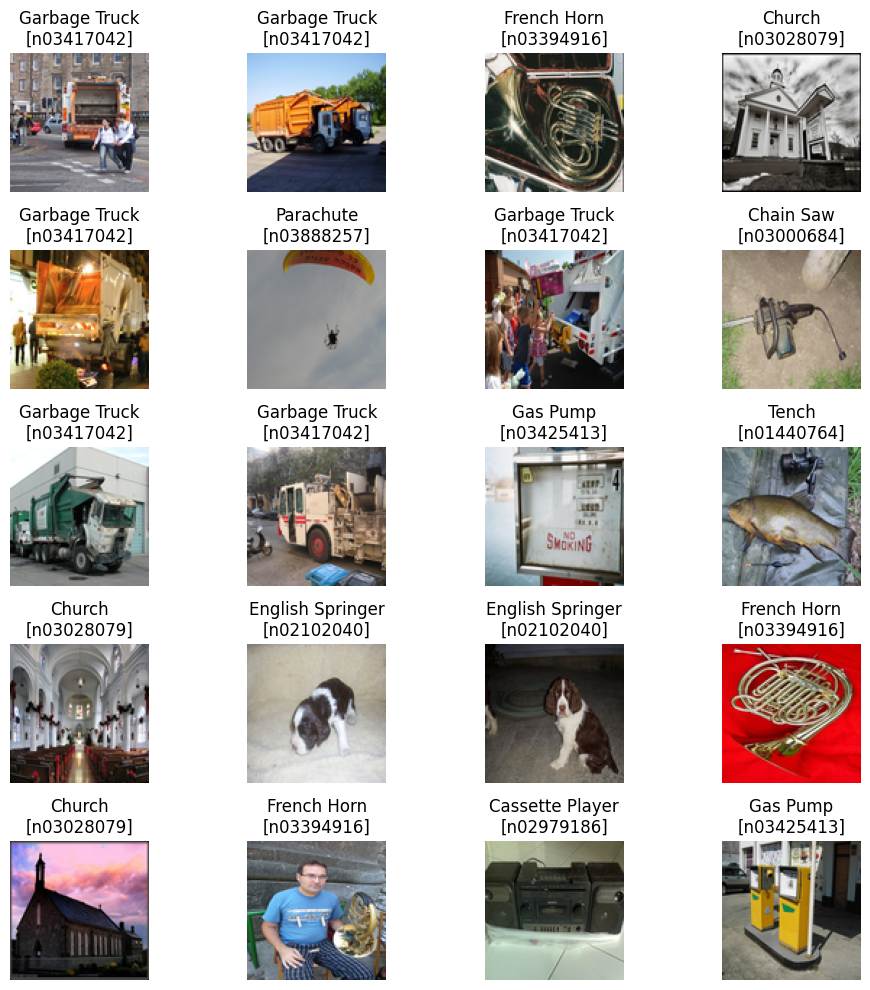

In [3]:
random_indices = cp.random.randint(0, len(train_loader), size=20)
train_loader.plot_batch(
    random_indices.get().tolist(),
    figsize=(10, 10),
    aug_chance=0.5,
    flip_chance=0.5
)

In [4]:
test_loader = ImagenetteDataLoader(
    root_path="input/imagenette2",
    split="val",
    target_size=(96, 96)
)

len(test_loader), test_loader.get_image_shape()

(3925, (3, 96, 96))

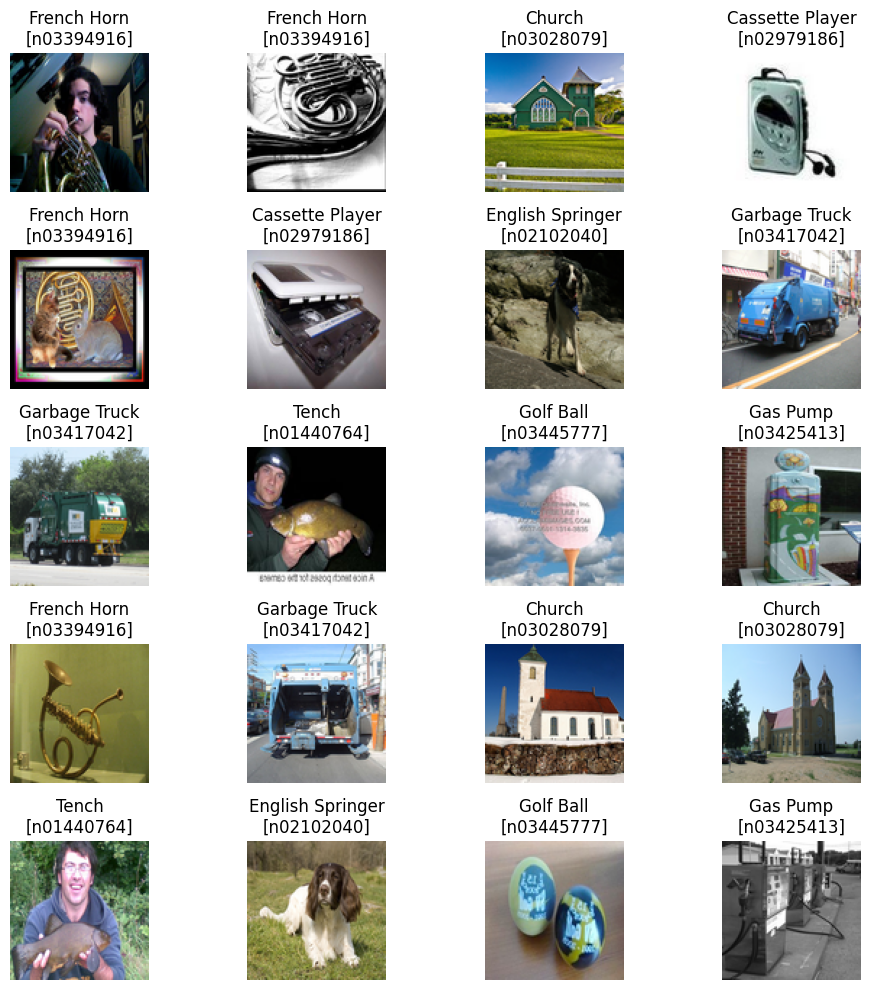

In [5]:
random_indices = cp.random.randint(0, len(test_loader), size=20)
test_loader.plot_batch(
    random_indices.get().tolist(),
    figsize=(10, 10),
    aug_chance=0.5,
    flip_chance=0.5
)

## Building the Model

In [6]:
feature_layers = [
    {"type": "ReLUConv", "num_filters": 16, "num_channels": 3, "kernel_height": 3, "kernel_width": 3, "padding": 1, "stride": 1},
    {"type": "ReLUConv", "num_filters": 16, "num_channels": 16, "kernel_height": 3, "kernel_width": 3, "padding": 1, "stride": 1},
    {"type": "MaxPool", "pool_height": 2, "pool_width": 2, "stride": 2},
    {"type": "ReLUConv", "num_filters": 32, "num_channels": 16, "kernel_height": 3, "kernel_width": 3, "padding": 1, "stride": 1},
    {"type": "ReLUConv", "num_filters": 32, "num_channels": 32, "kernel_height": 3, "kernel_width": 3, "padding": 1, "stride": 1},
    {"type": "MaxPool", "pool_height": 2, "pool_width": 2, "stride": 2},
    {"type": "ReLUConv", "num_filters": 64, "num_channels": 32, "kernel_height": 3, "kernel_width": 3, "padding": 1, "stride": 1},
    {"type": "MaxPool", "pool_height": 2, "pool_width": 2, "stride": 2},
    {"type": "ReLUConv", "num_filters": 64, "num_channels": 64, "kernel_height": 3, "kernel_width": 3, "padding": 1, "stride": 2},
    {"type": "ReLUConv", "num_filters": 64, "num_channels": 64, "kernel_height": 3, "kernel_width": 3, "padding": 0, "stride": 1},
    {"type": "MaxPool", "pool_height": 2, "pool_width": 2, "stride": 2},
    {"type": "Flatten"}
]

warmup_input, _ = train_loader.load_batch(indices=[0], normalize=True)
feature_extractor = Network(layer_definitions=feature_layers)
classifier_input_size = int(feature_extractor.forward(input=warmup_input)[-1].shape[1])

layer_definitions = feature_layers + [
    {"type": "Softmax", "input_size": classifier_input_size, "num_neurons": 10},
]

network = Network(layer_definitions=layer_definitions)

In [7]:
network.describe()

Network Architecture

Layer 1: ReluConvLayer
  Filters Shape: (16, 3, 3, 3) | Biases Shape: (16,)
  Parameters: 448

Layer 2: ReluConvLayer
  Filters Shape: (16, 16, 3, 3) | Biases Shape: (16,)
  Parameters: 2,320

Layer 3: MaxPoolLayer
  Pool Shape: (2, 2) | Stride: 2

Layer 4: ReluConvLayer
  Filters Shape: (32, 16, 3, 3) | Biases Shape: (32,)
  Parameters: 4,640

Layer 5: ReluConvLayer
  Filters Shape: (32, 32, 3, 3) | Biases Shape: (32,)
  Parameters: 9,248

Layer 6: MaxPoolLayer
  Pool Shape: (2, 2) | Stride: 2

Layer 7: ReluConvLayer
  Filters Shape: (64, 32, 3, 3) | Biases Shape: (64,)
  Parameters: 18,496

Layer 8: MaxPoolLayer
  Pool Shape: (2, 2) | Stride: 2

Layer 9: ReluConvLayer
  Filters Shape: (64, 64, 3, 3) | Biases Shape: (64,)
  Parameters: 36,928

Layer 10: ReluConvLayer
  Filters Shape: (64, 64, 3, 3) | Biases Shape: (64,)
  Parameters: 36,928

Layer 11: MaxPoolLayer
  Pool Shape: (2, 2) | Stride: 2

Layer 12: FlattenLayer
  Parameters: 0

Layer 13: SoftmaxLayer
  W

In [8]:
print("Input Shape:", warmup_input.shape)
_ = network.forward(input=warmup_input, print_shapes=True)

Input Shape: (1, 3, 96, 96)
Layer 0 Output Shape: (1, 16, 96, 96)
Layer 1 Output Shape: (1, 16, 96, 96)
Layer 2 Output Shape: (1, 16, 48, 48)
Layer 3 Output Shape: (1, 32, 48, 48)
Layer 4 Output Shape: (1, 32, 48, 48)
Layer 5 Output Shape: (1, 32, 24, 24)
Layer 6 Output Shape: (1, 64, 24, 24)
Layer 7 Output Shape: (1, 64, 12, 12)
Layer 8 Output Shape: (1, 64, 6, 6)
Layer 9 Output Shape: (1, 64, 4, 4)
Layer 10 Output Shape: (1, 64, 2, 2)
Layer 11 Output Shape: (1, 256)
Layer 12 Output Shape: (1, 10)


## Building the Train/Eval Loops

In [9]:
def evaluate_model(model, data_loader, batch_size):
    total_loss = 0.0
    correct_predictions = 0
    num_samples = 0
    num_batches = (len(data_loader) + batch_size - 1) // batch_size

    for x_batch, y_batch in data_loader.iter_batches(
        batch_size=batch_size,
        normalize=True,
        one_hot=True,
        shuffle=False
    ):
        outputs = model.forward(input=x_batch)
        y_pred = outputs[-1]

        total_loss += model.cce_loss(y_pred=y_pred, y_true=y_batch).item()

        predicted_labels = cp.argmax(y_pred, axis=1)
        true_labels = cp.argmax(y_batch, axis=1)

        correct_predictions += cp.sum(predicted_labels == true_labels).item()
        num_samples += x_batch.shape[0]

    avg_loss = total_loss / num_batches
    accuracy = correct_predictions / num_samples

    return avg_loss, accuracy

In [ ]:
def train_model(model, 
                train_loader, 
                test_loader, 
                batch_size=16, 
                epochs=10, 
                base_learning_rate=0.003, 
                min_learning_rate=0.0001, 
                weight_decay_lambda=0.0,
                stop_early_patience=10):
    train_num_batches = (len(train_loader) + batch_size - 1) // batch_size
    total_steps = epochs * train_num_batches
    global_step = 0

    best_model = model.clone()
    best_model_accuracy = 0.0

    epochs_without_improvement = 0

    epoch_summaries = []

    for epoch in range(epochs):
        total_loss = 0.0

        for _, (x_batch, y_batch) in enumerate(
            train_loader.iter_batches(
                batch_size=batch_size, 
                normalize=True, 
                one_hot=True, 
                shuffle=True, 
                aug_chance=0.5, 
                flip_chance=0.5
            ), start=1
        ):
            learning_rate = min_learning_rate + 0.5 * (base_learning_rate - min_learning_rate) * (1 + math.cos(math.pi * global_step / total_steps))

            outputs = model.forward(input=x_batch)
            y_pred = outputs[-1]

            error = y_pred - y_batch
            loss = model.cce_loss(y_pred=y_pred, y_true=y_batch).item()
            total_loss += loss

            model.backward(output_error=error, batch_size=x_batch.shape[0])
            model.update_parameters(learning_rate=learning_rate, weight_decay_lambda=weight_decay_lambda)

            global_step += 1

        train_loss = total_loss / train_num_batches
        test_loss, test_accuracy = evaluate_model(
            model=model, 
            data_loader=test_loader, 
            batch_size=batch_size
        )

        if test_accuracy > best_model_accuracy:
            best_model = model.clone()
            best_model_accuracy = test_accuracy
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        epoch_summary = {
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "test_loss": test_loss,
            "test_accuracy": test_accuracy
        }
        epoch_summaries.append(epoch_summary)
        print(epoch_summary)
        
        if stop_early_patience and epochs_without_improvement >= stop_early_patience:
            print(f"Stopping early after {epoch + 1} epochs due to no improvement.")
            break

    return best_model, epoch_summaries

## Training the Model

In [11]:
batch_size = 16
epochs = 100
base_learning_rate = 0.01
min_learning_rate = 0.0001
weight_decay_lambda = 0.0005
stop_early_patience = 10

best_model, epoch_summaries = train_model(
    model=network,
    train_loader=train_loader,
    test_loader=test_loader,
    batch_size=batch_size,
    epochs=epochs,
    base_learning_rate=base_learning_rate,
    min_learning_rate=min_learning_rate,
    weight_decay_lambda=weight_decay_lambda,
    stop_early_patience=stop_early_patience
)

{'epoch': 1, 'train_loss': 2.0981073994341344, 'test_loss': 1.8096368975393968, 'test_accuracy': 0.37630573248407645}
{'epoch': 2, 'train_loss': 1.7224094707480349, 'test_loss': 1.7017996913974054, 'test_accuracy': 0.42394904458598726}
{'epoch': 3, 'train_loss': 1.5139548057808496, 'test_loss': 1.5049759605630033, 'test_accuracy': 0.4973248407643312}
{'epoch': 4, 'train_loss': 1.389655875589731, 'test_loss': 1.3943908856850509, 'test_accuracy': 0.5505732484076433}
{'epoch': 5, 'train_loss': 1.278612639256199, 'test_loss': 1.3572344785932646, 'test_accuracy': 0.56}
{'epoch': 6, 'train_loss': 1.1981372981449614, 'test_loss': 1.1652608700809783, 'test_accuracy': 0.6244585987261146}
{'epoch': 7, 'train_loss': 1.1252886193334484, 'test_loss': 1.120883417428862, 'test_accuracy': 0.6435668789808917}
{'epoch': 8, 'train_loss': 1.0787569121880787, 'test_loss': 1.168205236963974, 'test_accuracy': 0.6224203821656051}
{'epoch': 9, 'train_loss': 1.0204743772412563, 'test_loss': 1.085742946773813, '

## Evaluating the Model

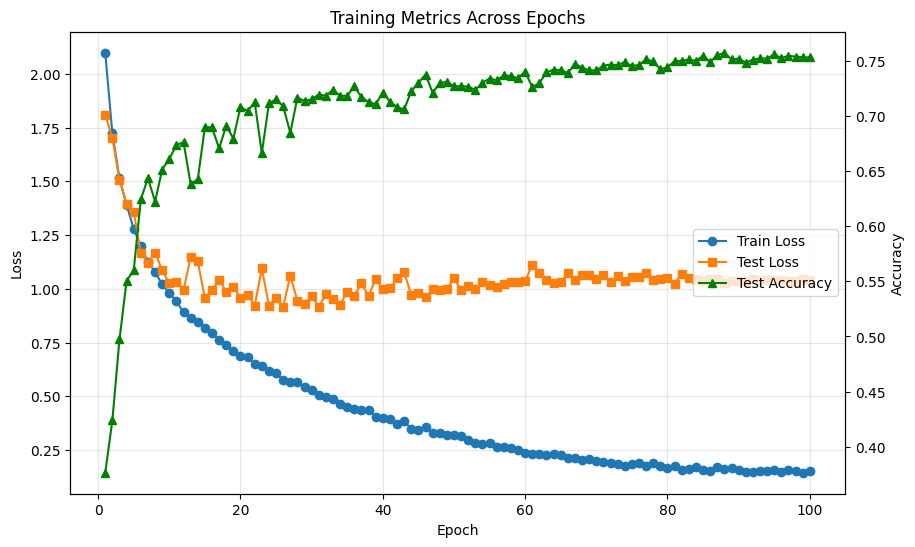

In [12]:
epochs_plot = [summary["epoch"] for summary in epoch_summaries]
train_losses = [summary["train_loss"] for summary in epoch_summaries]
test_losses = [summary["test_loss"] for summary in epoch_summaries]
test_accuracies = [summary["test_accuracy"] for summary in epoch_summaries]

fig, ax1 = plt.subplots(figsize=(10, 6))

line1 = ax1.plot(epochs_plot, train_losses, marker="o", label="Train Loss")
line2 = ax1.plot(epochs_plot, test_losses, marker="s", label="Test Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
line3 = ax2.plot(epochs_plot, test_accuracies, marker="^", color="green", label="Test Accuracy")
ax2.set_ylabel("Accuracy")

lines = line1 + line2 + line3
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="center right")

plt.title("Training Metrics Across Epochs")
plt.show()

In [14]:
train_loss, train_accuracy = evaluate_model(
    model=best_model, 
    data_loader=train_loader, 
    batch_size=batch_size
)

print(f"Final Train Loss: {train_loss:.6f} | Final Train Accuracy: {train_accuracy:.4f}")

Final Train Loss: 0.022385 | Final Train Accuracy: 0.9996


In [15]:
test_loss, test_accuracy = evaluate_model(
    model=best_model, 
    data_loader=test_loader, 
    batch_size=batch_size
)

print(f"Final Test Loss: {test_loss:.6f} | Final Test Accuracy: {test_accuracy:.4f}")

Final Test Loss: 1.027238 | Final Test Accuracy: 0.7575
